In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from lazy5.inspect import get_attrs_dset
import os
from crikit.preprocess.denoise import SVDDecompose, SVDRecompose
from crikit.cri.kk import KramersKronig
from crikit.cri.error_correction import PhaseErrCorrectALS

In [2]:
DATA_FOLDER = "."
filename = "preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_03.h5"
f = h5py.File(os.path.join(DATA_FOLDER,filename), 'r')
# Access the group
preprocessed_group = f['preprocessed_images']

# Print the names of items within the group
print("Items within the 'preprocessed_images' group:")
for key in preprocessed_group.keys():
    print(key)
# Access the 'medfilter_ratio' dataset within the 'preprocessed_images' group
ratio = f['preprocessed_images/medfilter_ratio']

# Print the shape of the extracted dataset
print("Shape of 'medfilter_ratio' dataset:", ratio.shape)
attrs = get_attrs_dset(filename, 'preprocessed_images/medfilter_ratio')

Items within the 'preprocessed_images' group:
medfilter_dark
medfilter_nrb_for_ratio
medfilter_ratio
Shape of 'medfilter_ratio' dataset: (320, 500, 2304)


In [3]:
#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe


In [18]:

# Select wn values between 400 and 1800
wn_mask = (wn >= 400) & (wn <= 1800)
wn_selected = wn[wn_mask]
indices = np.where(wn_mask)[0]
ratio_selected = ratio[:, :, indices]
signature_index = 514
point_signal = [106, 336]  # Example point (y, x)
point_noise = [100, 100]  # Example point (y, x)

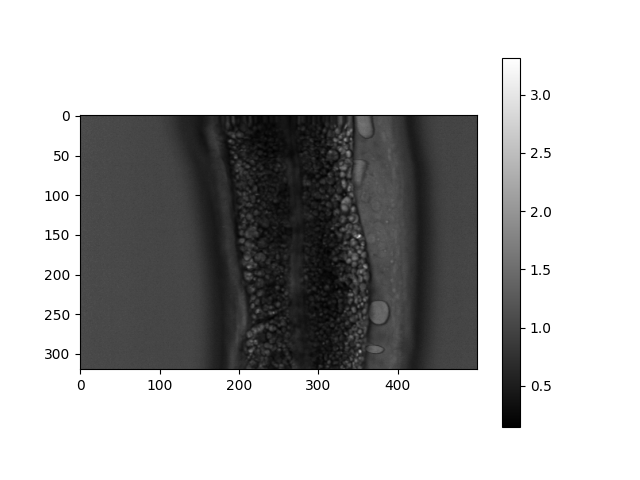

In [19]:
%matplotlib widget
plt.imshow(ratio[:,:,signature_index], cmap='gray')
plt.colorbar()

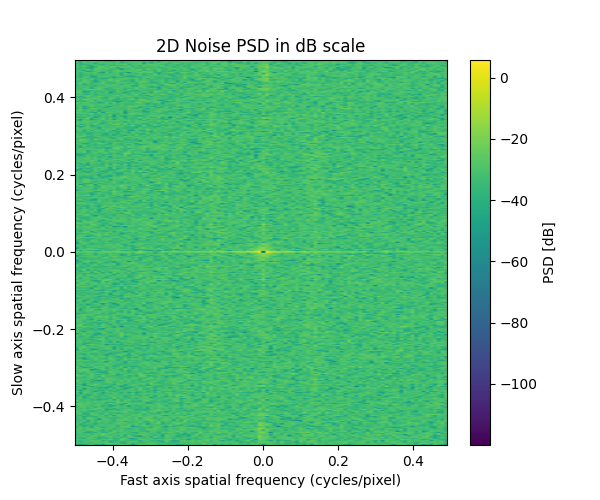

In [20]:
img = ratio[:, 0:100, signature_index]
def psd_via_autocorr(img):
    img = np.asarray(img, dtype=float)
    Ny, Nx = img.shape
    x = img - img.mean()

    F = np.fft.fft2(x)
    R = np.fft.ifft2(np.abs(F)**2).real
    R = np.fft.fftshift(R) / (Ny * Nx)

    PSD = np.fft.fft2(np.fft.ifftshift(R))
    PSD = np.abs(PSD).real
    PSD = np.fft.fftshift(PSD)

    fy = np.fft.fftshift(np.fft.fftfreq(Ny))
    fx = np.fft.fftshift(np.fft.fftfreq(Nx))
    return fy, fx, PSD, R


fy, fx, PSD2, R2 = psd_via_autocorr(img)

# Avoid log of zero
PSD_dB = 10 * np.log10(PSD2 + 1e-12)

plt.figure(figsize=(6,5))
plt.imshow(PSD_dB,
           extent=[fx[0], fx[-1], fy[0], fy[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='PSD [dB]')
plt.xlabel('Fast axis spatial frequency (cycles/pixel)')
plt.ylabel('Slow axis spatial frequency (cycles/pixel)')
plt.title('2D Noise PSD in dB scale')
plt.show()


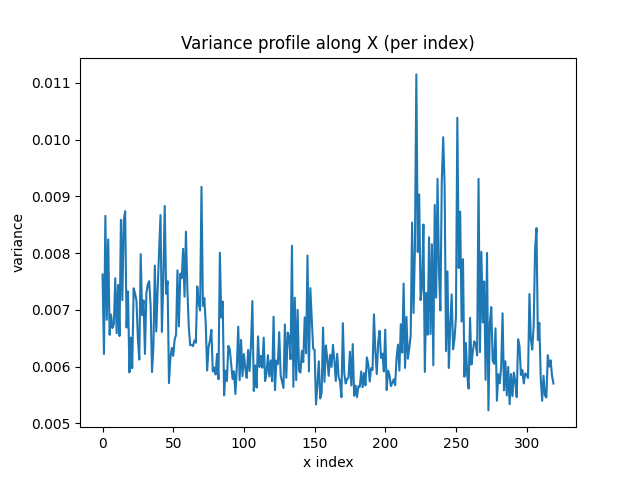

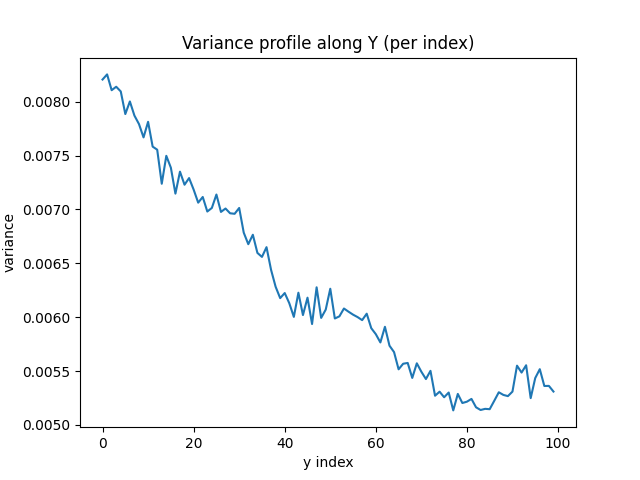

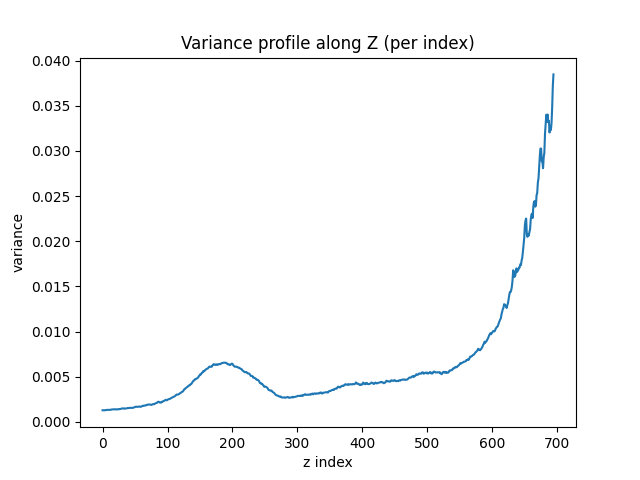

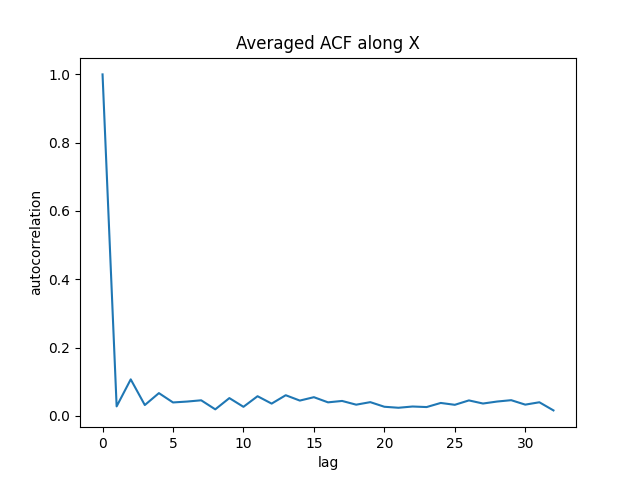

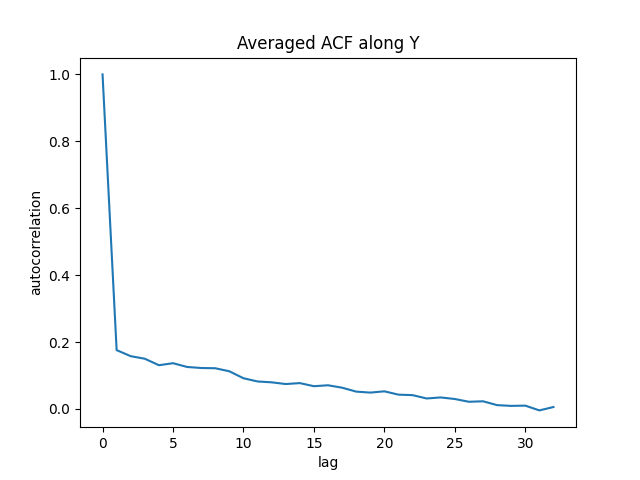

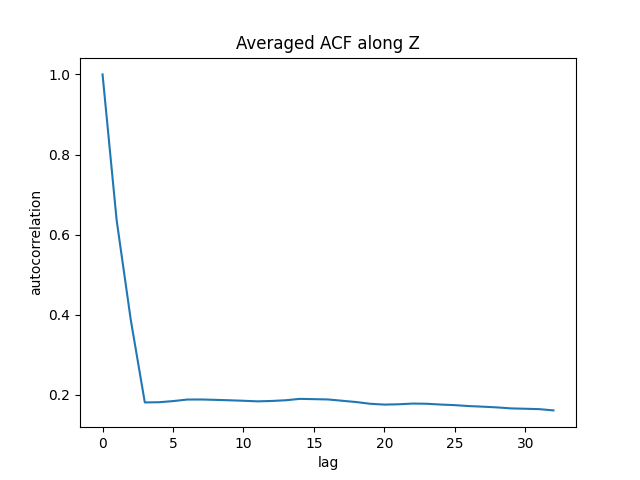

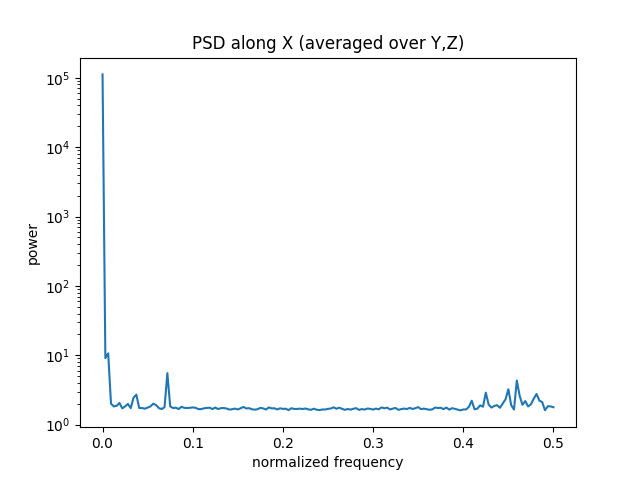

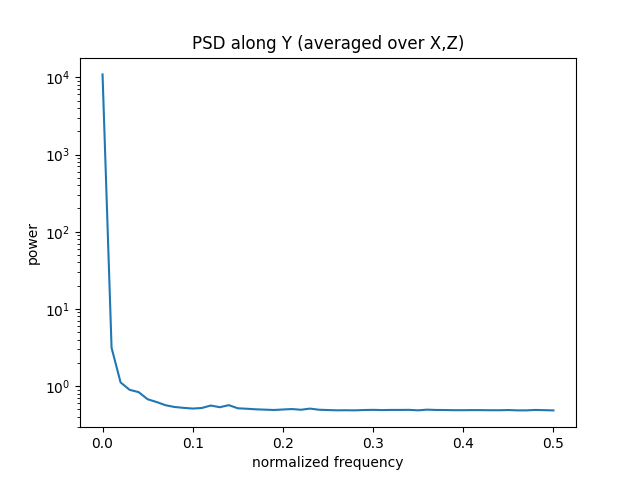

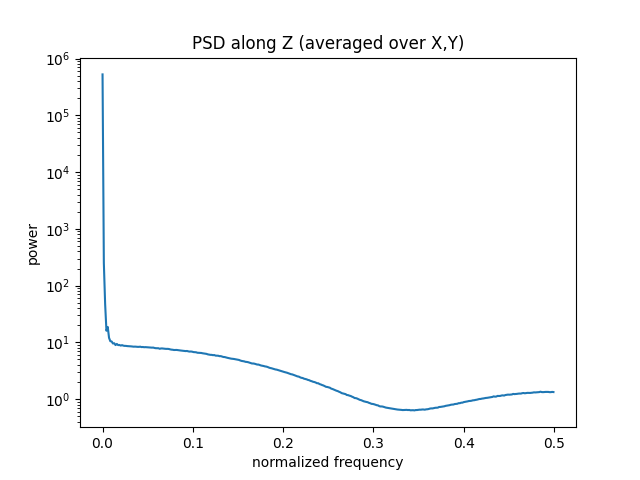

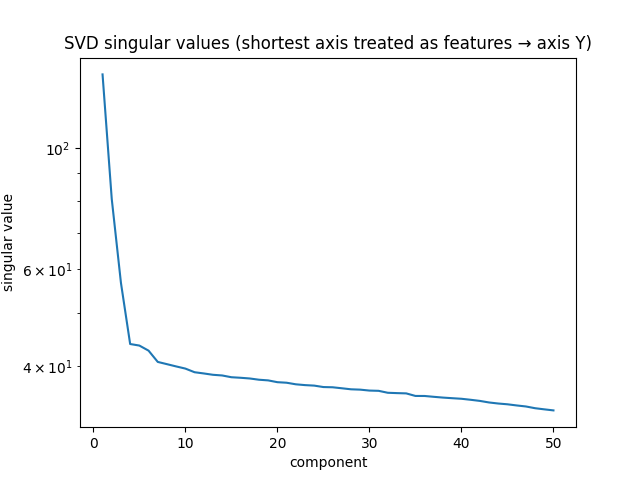

'\nbase = "."\nos.makedirs(base, exist_ok=True)\n\n# Summary stats\nsummary = pd.DataFrame({\n    "nx": [nx],\n    "ny": [ny],\n    "nz": [nz],\n    "mean": [mu],\n    "std": [sigma],\n    "var_x_mean": [float(np.mean(var_x))],\n    "var_y_mean": [float(np.mean(var_y))],\n    "var_z_mean": [float(np.mean(var_z))]\n})\nsummary_csv = os.path.join(base, "summary_stats.csv")\nsummary.to_csv(summary_csv, index=False)\n\n# ACF CSVs\nacf_x_csv = save_csv(os.path.join(base, "acf_x.csv"), ["lag", "acf"], np.vstack([lags_x, acf_x]).T if acf_x.size else np.zeros((0,2)))\nacf_y_csv = save_csv(os.path.join(base, "acf_y.csv"), ["lag", "acf"], np.vstack([lags_y, acf_y]).T if acf_y.size else np.zeros((0,2)))\nacf_z_csv = save_csv(os.path.join(base, "acf_z.csv"), ["lag", "acf"], np.vstack([lags_z, acf_z]).T if acf_z.size else np.zeros((0,2)))\n\n# PSD CSVs\npsd_x_csv = save_csv(os.path.join(base, "psd_x.csv"), ["freq", "power"], np.vstack([freq_x, psd_x]).T)\npsd_y_csv = save_csv(os.path.join(base, "ps

In [21]:
img = ratio[:, 0:100, indices]
# Noise characterization toolkit for a 3D cube `img`.
# This script:
# 1) Computes per-axis variance profiles
# 2) Computes averaged autocorrelation (ACF) along each axis
# 3) Computes power spectral density (PSD) along each axis (via FFT)
# 4) (Optional) Computes SVD on the shortest axis orientation to reveal correlated noise structure
# It will work with your `img` variable if it exists in the environment;
# otherwise it will generate a synthetic noisy cube for demonstration.
#
# Outputs:
# - Plots for variance profiles, ACF, PSD, and SVD spectrum (if computed)
# - CSV files for PSD and ACF (per axis) + a summary CSV with basic stats
# - The CSVs are saved under /mnt/data, and download links will be printed at the end.
#
# Usage: just run this cell. To use your own data, define `img` beforehand as a NumPy array with shape (nx, ny, nz).

import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from typing import Tuple, List

# ---------------------- Utilities ----------------------
def ensure_img() -> np.ndarray:
    g = globals()
    if "img" in g and isinstance(g["img"], np.ndarray) and g["img"].ndim == 3:
        return g["img"]
    # Synthetic demo cube: mostly white noise + mild correlation along z
    np.random.seed(0)
    nx, ny, nz = 128, 100, 64
    white = np.random.normal(0, 1.0, (nx, ny, nz))
    # Impose slight AR(1) correlation along z
    rho = 0.7
    ar = np.zeros_like(white)
    ar[..., 0] = white[..., 0]
    for k in range(1, nz):
        ar[..., k] = rho * ar[..., k-1] + np.sqrt(1 - rho**2) * white[..., k]
    # Add mild striping along x
    stripe = (np.random.normal(0, 0.1, (nx, 1, 1)) * np.ones((nx, ny, nz)))
    cube = ar + stripe
    return cube

def variance_profiles(cube: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    var_x = np.var(cube, axis=(1,2))
    var_y = np.var(cube, axis=(0,2))
    var_z = np.var(cube, axis=(0,1))
    return var_x, var_y, var_z

def mean_std_global(cube: np.ndarray) -> Tuple[float, float]:
    return float(np.mean(cube)), float(np.std(cube))

def acf_1d(x: np.ndarray, max_lag: int) -> np.ndarray:
    x = x - np.mean(x)
    if np.allclose(np.std(x), 0):
        return np.zeros(max_lag + 1)
    c = np.correlate(x, x, mode="full")
    mid = c.size // 2
    c = c[mid:mid + max_lag + 1]
    c = c / c[0] if c[0] != 0 else c
    return c

def averaged_acf_along_axis(cube: np.ndarray, axis: int, max_lag: int = 32, samples: int = 512) -> Tuple[np.ndarray, np.ndarray]:
    # Sample random lines along the chosen axis and average their ACFs
    nx, ny, nz = cube.shape
    rng = np.random.default_rng(42)
    acfs = []
    if axis == 0:
        # Lines are cube[:, y, z]
        ys = rng.integers(0, ny, size=samples)
        zs = rng.integers(0, nz, size=samples)
        for y, z in zip(ys, zs):
            acfs.append(acf_1d(cube[:, y, z], min(max_lag, nx - 1)))
        L = min(max_lag, nx - 1)
    elif axis == 1:
        xs = rng.integers(0, nx, size=samples)
        zs = rng.integers(0, nz, size=samples)
        for x, z in zip(xs, zs):
            acfs.append(acf_1d(cube[x, :, z], min(max_lag, ny - 1)))
        L = min(max_lag, ny - 1)
    else:
        xs = rng.integers(0, nx, size=samples)
        ys = rng.integers(0, ny, size=samples)
        for x, y in zip(xs, ys):
            acfs.append(acf_1d(cube[x, y, :], min(max_lag, nz - 1)))
        L = min(max_lag, nz - 1)
    acfs = np.array(acfs)
    if acfs.size == 0:
        return np.arange(0), np.array([])
    acf_mean = np.nanmean(acfs, axis=0)
    lags = np.arange(acf_mean.size)
    return lags, acf_mean

def psd_along_axis(cube: np.ndarray, axis: int) -> Tuple[np.ndarray, np.ndarray]:
    # Compute average (over the other axes) periodogram (|FFT|^2)
    # Use rfft for real input for efficiency; convert to one-sided frequencies
    nx, ny, nz = cube.shape
    if axis == 0:
        F = np.fft.rfft(cube, axis=0)
        ps = np.mean(np.abs(F) ** 2, axis=(1,2))
        n = nx
    elif axis == 1:
        F = np.fft.rfft(cube, axis=1)
        ps = np.mean(np.abs(F) ** 2, axis=(0,2))
        n = ny
    else:
        F = np.fft.rfft(cube, axis=2)
        ps = np.mean(np.abs(F) ** 2, axis=(0,1))
        n = nz
    freqs = np.fft.rfftfreq(n, d=1.0)
    return freqs, ps

def svd_on_shortest_axis(cube: np.ndarray, max_components: int = 50) -> Tuple[np.ndarray, int]:
    # Reshape cube so that the shortest axis becomes "features"
    nx, ny, nz = cube.shape
    axes_lengths = [nx, ny, nz]
    shortest = int(np.argmin(axes_lengths))
    if shortest == 0:
        X = cube.reshape(nx, ny * nz)
        X = X - X.mean(axis=1, keepdims=True)
        # Compute SVD of X (n_short x N)
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
    elif shortest == 1:
        X = np.transpose(cube, (1, 0, 2)).reshape(ny, nx * nz)
        X = X - X.mean(axis=1, keepdims=True)
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
    else:
        X = cube.reshape(nx * ny, nz)
        X = X - X.mean(axis=0, keepdims=True)
        # SVD on (N x n_short); we want singular values tied to the shortest axis
        # We compute SVD of the transposed to get n_short singular values efficiently if needed
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
    k = min(len(s), max_components)
    return s[:k], shortest

def save_csv(path: str, header: List[str], data: np.ndarray):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame(data, columns=header)
    df.to_csv(path, index=False)
    return path

# ---------------------- Run analysis ----------------------
cube = ensure_img()
nx, ny, nz = cube.shape

# 1) Variance profiles
var_x, var_y, var_z = variance_profiles(cube)
mu, sigma = mean_std_global(cube)

# 2) ACF (averaged) along each axis
lags_x, acf_x = averaged_acf_along_axis(cube, axis=0, max_lag=32, samples=256)
lags_y, acf_y = averaged_acf_along_axis(cube, axis=1, max_lag=32, samples=256)
lags_z, acf_z = averaged_acf_along_axis(cube, axis=2, max_lag=32, samples=256)

# 3) PSD along each axis
freq_x, psd_x = psd_along_axis(cube, axis=0)
freq_y, psd_y = psd_along_axis(cube, axis=1)
freq_z, psd_z = psd_along_axis(cube, axis=2)

# 4) SVD on shortest axis
svals, shortest_axis = svd_on_shortest_axis(cube, max_components=50)

# ---------------------- Plots (one per chart) ----------------------

# Variance profiles
plt.figure()
plt.plot(var_x)
plt.title("Variance profile along X (per index)")
plt.xlabel("x index")
plt.ylabel("variance")
plt.show()

plt.figure()
plt.plot(var_y)
plt.title("Variance profile along Y (per index)")
plt.xlabel("y index")
plt.ylabel("variance")
plt.show()

plt.figure()
plt.plot(var_z)
plt.title("Variance profile along Z (per index)")
plt.xlabel("z index")
plt.ylabel("variance")
plt.show()

# ACF plots
if acf_x.size > 0:
    plt.figure()
    plt.plot(lags_x, acf_x)
    plt.title("Averaged ACF along X")
    plt.xlabel("lag")
    plt.ylabel("autocorrelation")
    plt.show()

if acf_y.size > 0:
    plt.figure()
    plt.plot(lags_y, acf_y)
    plt.title("Averaged ACF along Y")
    plt.xlabel("lag")
    plt.ylabel("autocorrelation")
    plt.show()

if acf_z.size > 0:
    plt.figure()
    plt.plot(lags_z, acf_z)
    plt.title("Averaged ACF along Z")
    plt.xlabel("lag")
    plt.ylabel("autocorrelation")
    plt.show()

# PSD plots
plt.figure()
plt.plot(freq_x, psd_x)
plt.title("PSD along X (averaged over Y,Z)")
plt.xlabel("normalized frequency")
plt.ylabel("power")
plt.yscale("log")
plt.show()

plt.figure()
plt.plot(freq_y, psd_y)
plt.title("PSD along Y (averaged over X,Z)")
plt.xlabel("normalized frequency")
plt.ylabel("power")
plt.yscale("log")
plt.show()

plt.figure()
plt.plot(freq_z, psd_z)
plt.title("PSD along Z (averaged over X,Y)")
plt.xlabel("normalized frequency")
plt.ylabel("power")
plt.yscale("log")
plt.show()

# SVD spectrum
plt.figure()
plt.plot(np.arange(1, len(svals)+1), svals)
ax_label = ["X", "Y", "Z"][shortest_axis]
plt.title(f"SVD singular values (shortest axis treated as features → axis {ax_label})")
plt.xlabel("component")
plt.ylabel("singular value")
plt.yscale("log")
plt.show()

# ---------------------- Save CSVs ----------------------
"""
base = "."
os.makedirs(base, exist_ok=True)

# Summary stats
summary = pd.DataFrame({
    "nx": [nx],
    "ny": [ny],
    "nz": [nz],
    "mean": [mu],
    "std": [sigma],
    "var_x_mean": [float(np.mean(var_x))],
    "var_y_mean": [float(np.mean(var_y))],
    "var_z_mean": [float(np.mean(var_z))]
})
summary_csv = os.path.join(base, "summary_stats.csv")
summary.to_csv(summary_csv, index=False)

# ACF CSVs
acf_x_csv = save_csv(os.path.join(base, "acf_x.csv"), ["lag", "acf"], np.vstack([lags_x, acf_x]).T if acf_x.size else np.zeros((0,2)))
acf_y_csv = save_csv(os.path.join(base, "acf_y.csv"), ["lag", "acf"], np.vstack([lags_y, acf_y]).T if acf_y.size else np.zeros((0,2)))
acf_z_csv = save_csv(os.path.join(base, "acf_z.csv"), ["lag", "acf"], np.vstack([lags_z, acf_z]).T if acf_z.size else np.zeros((0,2)))

# PSD CSVs
psd_x_csv = save_csv(os.path.join(base, "psd_x.csv"), ["freq", "power"], np.vstack([freq_x, psd_x]).T)
psd_y_csv = save_csv(os.path.join(base, "psd_y.csv"), ["freq", "power"], np.vstack([freq_y, psd_y]).T)
psd_z_csv = save_csv(os.path.join(base, "psd_z.csv"), ["freq", "power"], np.vstack([freq_z, psd_z]).T)

# SVD CSV
svd_csv = save_csv(os.path.join(base, "svd_singular_values.csv"), ["component", "singular_value"], np.vstack([np.arange(1, len(svals)+1), svals]).T)

# Print download links
links = {
    "summary_stats.csv": summary_csv,
    "acf_x.csv": acf_x_csv,
    "acf_y.csv": acf_y_csv,
    "acf_z.csv": acf_z_csv,
    "psd_x.csv": psd_x_csv,
    "psd_y.csv": psd_y_csv,
    "psd_z.csv": psd_z_csv,
    "svd_singular_values.csv": svd_csv,
}

for name, path in links.items():
    print(f"{name}: sandbox:{path}")
"""

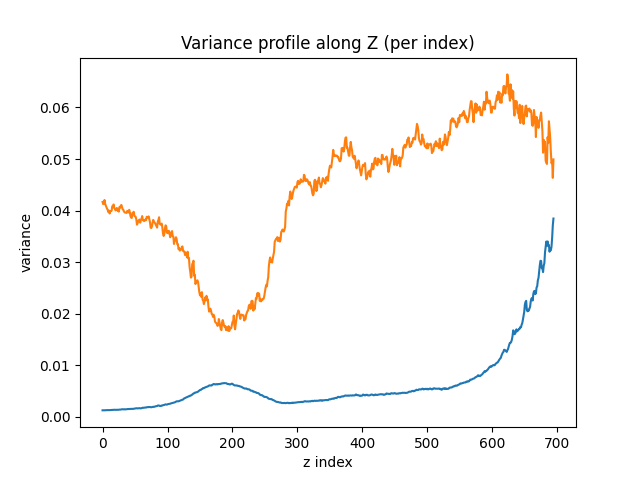

In [24]:
plt.figure()
plt.plot(var_z)
plt.plot(np.average(img, axis=(0,1))-1)
plt.title("Variance profile along Z (per index)")
plt.xlabel("z index")
plt.ylabel("variance")
plt.show()

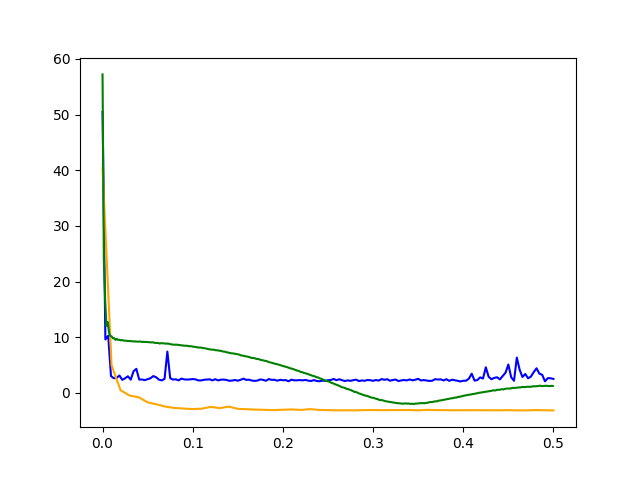

In [28]:
# PSD plots
plt.figure()
plt.plot(freq_x, 10*np.log10(psd_x), label='PSD_x',color='blue')
plt.plot(freq_y, 10*np.log10(psd_y), label='PSD_y',color='orange')
plt.plot(freq_z, 10*np.log10(psd_z), label='PSD_z',color='green')

plt.show()